# 03. Exploratory Data Analysis

Step 2에서 생성한 EDA용 cleaned dataset을 사용해 Pass(-1)와 Fail(1)의 Feature 분포, 효과크기, 상관관계 및 시간 패턴을 탐색한다. 익명 Feature를 실제 공정 변수로 추정하지 않으며 Feature selection이나 모델링은 수행하지 않는다.

In [1]:
import os
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
if not (PROJECT_ROOT / 'data' / 'processed').exists():
    raise RuntimeError(f'Project root could not be resolved from {cwd}')
os.environ['MPLCONFIGDIR'] = str(PROJECT_ROOT / '.cache' / 'matplotlib')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import Markdown, display

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'secom_cleaned_eda.csv'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 30)
print(f'Data: {DATA_PATH}')

Data: C:\Projects\semiconductor-secom-yield-analysis\data\processed\secom_cleaned_eda.csv


## 1. Load the cleaned EDA dataset

클래스 분포 자체는 Step 1에서 확인했다. 여기서는 Fail 표본이 적어 분포 추정과 검정력이 Pass보다 불안정하며, p-value만으로 Feature를 평가하면 안 된다는 점에 초점을 둔다.

In [2]:
df = pd.read_csv(DATA_PATH)
feature_columns = [c for c in df.columns if c not in {'timestamp', 'class'}]
X = df[feature_columns]
target = df['class']
class_counts = target.value_counts().sort_index()
assert X.shape == (1567, 442)
assert X.isna().sum().sum() == 0
assert set(target.unique()) == {-1, 1}
print(f'Cleaned numeric shape: {X.shape}')
display(pd.DataFrame({'count': class_counts, 'ratio': class_counts / len(df)}))
print('Fail 그룹은 전체의 6.64%이므로 시각화의 표본 밀도와 검정력 해석에 주의한다.')

Cleaned numeric shape: (1567, 442)


,count,ratio
class,,
-1,1463,0.933631
1,104,0.066369


Fail 그룹은 전체의 6.64%이므로 시각화의 표본 밀도와 검정력 해석에 주의한다.


## 2. Pass/Fail group statistics and standardized effect size

각 Feature에 대해 그룹별 mean, median, 표본표준편차를 계산한다. 표본 수가 크게 다르므로 Cohen's d의 소표본 편향을 보정한 **Hedges' g**를 사용한다. 부호는 `Fail - Pass`이며 양수면 Fail 평균이 더 높다. 효과크기는 단위가 다른 Feature를 비교할 수 있지만 인과관계나 예측 중요도를 뜻하지 않는다.

Welch t-test는 등분산을 가정하지 않는 탐색적 보조 검정으로 사용하고, 442개 동시 비교에는 Benjamini–Hochberg FDR을 적용한다.

In [3]:
pass_data = X[target == -1]
fail_data = X[target == 1]
n_pass, n_fail = len(pass_data), len(fail_data)
pass_mean, fail_mean = pass_data.mean(), fail_data.mean()
pass_median, fail_median = pass_data.median(), fail_data.median()
pass_std, fail_std = pass_data.std(ddof=1), fail_data.std(ddof=1)
pooled_std = np.sqrt(((n_pass - 1) * pass_std.pow(2) + (n_fail - 1) * fail_std.pow(2)) / (n_pass + n_fail - 2))
cohens_d = (fail_mean - pass_mean) / pooled_std
hedges_correction = 1 - 3 / (4 * (n_pass + n_fail) - 9)
hedges_g = cohens_d * hedges_correction
test_result = stats.ttest_ind(fail_data.to_numpy(), pass_data.to_numpy(), axis=0, equal_var=False, nan_policy='omit')
p_values = np.asarray(test_result.pvalue)
order = np.argsort(p_values)
ranked = p_values[order] * len(p_values) / np.arange(1, len(p_values) + 1)
adjusted_sorted = np.minimum.accumulate(ranked[::-1])[::-1]
p_fdr = np.empty_like(adjusted_sorted)
p_fdr[order] = np.clip(adjusted_sorted, 0, 1)
comparison = pd.DataFrame({
    'pass_mean': pass_mean, 'fail_mean': fail_mean,
    'pass_median': pass_median, 'fail_median': fail_median,
    'pass_std': pass_std, 'fail_std': fail_std,
    'mean_difference_fail_minus_pass': fail_mean - pass_mean,
    'hedges_g': hedges_g, 'abs_hedges_g': hedges_g.abs(),
    'welch_p_value': p_values, 'fdr_bh': p_fdr,
    'fdr_significant_0_05': p_fdr < 0.05,
}).sort_values('abs_hedges_g', ascending=False)
top_effect = comparison.head(20)
significant_count = int(comparison['fdr_significant_0_05'].sum())
comparison.to_csv(REPORTS_DIR / 'eda_feature_group_comparison.csv')
print(f'Pass n={n_pass:,}; Fail n={n_fail:,}')
print(f'FDR < 0.05 features: {significant_count:,} / {len(feature_columns):,}')
display(top_effect)

Pass n=1,463; Fail n=104
FDR < 0.05 features: 21 / 442


,pass_mean,fail_mean,pass_median,fail_median,pass_std,fail_std,mean_difference_fail_minus_pass,hedges_g,abs_hedges_g,welch_p_value,fdr_bh,fdr_significant_0_05
Attribute 60,2.555731,8.515123,0.7482,5.52230,9.291469,10.802344,5.959392,0.633783,0.633783,2.533797e-07,0.000056,True
Attribute 104,-0.009913,-0.008053,-0.0102,-0.00820,0.002993,0.003497,0.001860,0.613912,0.613912,6.033105e-07,0.000089,True
Attribute 511,54.430401,74.347949,46.4122,58.23240,35.746398,55.337152,19.917548,0.532970,0.532970,4.523193e-04,0.012495,True
Attribute 349,0.024263,0.030448,0.0226,0.02460,0.010263,0.024014,0.006185,0.529447,0.529447,1.037475e-02,0.134872,False
Attribute 432,21.187933,38.707342,16.2134,18.37995,31.825142,73.815053,17.519410,0.484777,0.484777,1.792923e-02,0.176105,False
Attribute 435,13.716830,28.954783,10.1575,11.31370,29.200664,73.104429,15.237952,0.449461,0.449461,3.689863e-02,0.262428,False
Attribute 431,17.364169,33.156115,10.9889,13.25580,31.468287,73.857500,15.791946,0.440483,0.440483,3.251427e-02,0.247781,False
Attribute 22,-5636.360219,-5363.822115,-5528.7500,-5447.50000,593.603033,945.885433,272.538103,0.437291,0.437291,4.541090e-03,0.069212,False
Attribute 436,8.373389,23.306973,4.5274,4.74350,29.340621,74.215847,14.933584,0.436991,0.436991,4.377978e-02,0.275837,False
Attribute 29,69.597730,68.111542,69.2444,68.19445,3.452199,3.265726,-1.486188,-0.431794,0.431794,1.807405e-05,0.001997,True


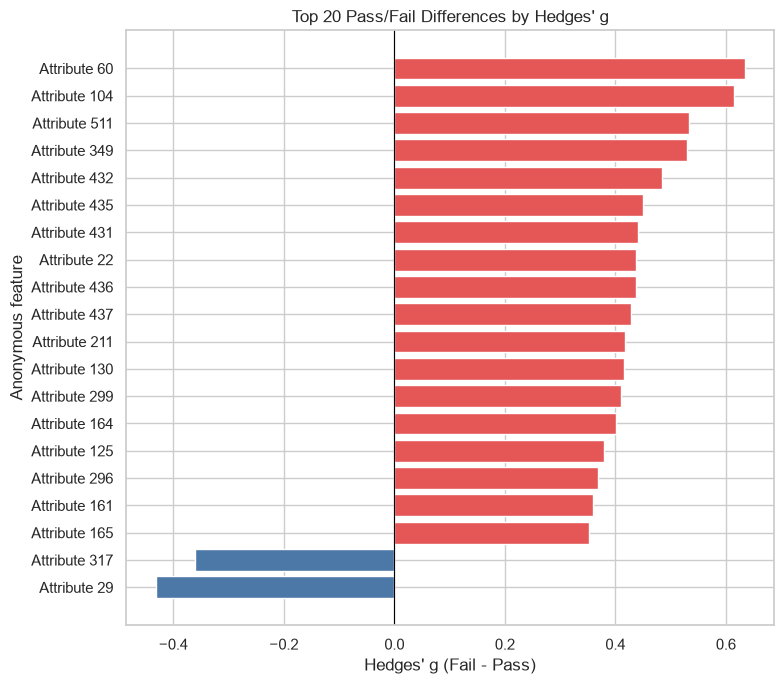

In [4]:
plot_effect = top_effect.sort_values('hedges_g')
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#E45756' if value > 0 else '#4C78A8' for value in plot_effect['hedges_g']]
ax.barh(plot_effect.index, plot_effect['hedges_g'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title="Top 20 Pass/Fail Differences by Hedges' g", xlabel="Hedges' g (Fail - Pass)", ylabel='Anonymous feature')
fig.tight_layout()
effect_figure = FIGURES_DIR / 'eda_top20_hedges_g.png'
fig.savefig(effect_figure, dpi=160, bbox_inches='tight')
plt.show()

## 3. Distribution comparison for the strongest effects

상위 6개 Feature를 boxplot으로 비교한다. Boxplot은 각 그룹의 median과 IQR을 독립적으로 보여주므로 표본 수 차이에 면적이 직접 지배되지 않는다. Outlier 표시는 숨겨 중앙 분포를 읽기 쉽게 하지만, 실제 이상치를 제거한 것은 아니다. Fail n=104이므로 Fail 분포는 Pass보다 불확실하다.

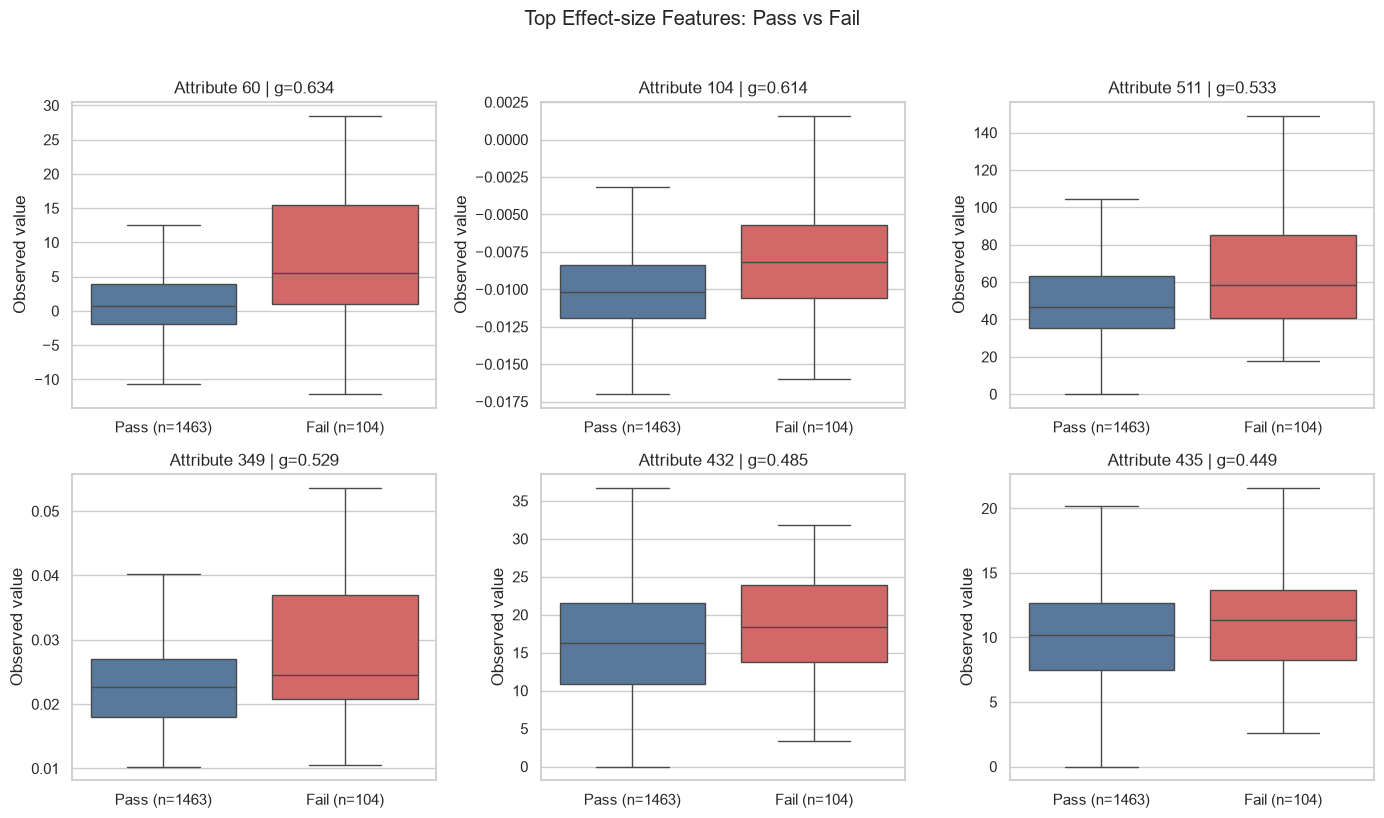

In [5]:
top6 = top_effect.index[:6].tolist()
long_top6 = df.melt(id_vars='class', value_vars=top6, var_name='feature', value_name='value')
long_top6['class_label'] = long_top6['class'].map({-1: f'Pass (n={n_pass})', 1: f'Fail (n={n_fail})'})
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for feature, ax in zip(top6, axes.flat):
    subset = long_top6[long_top6['feature'] == feature]
    sns.boxplot(data=subset, x='class_label', y='value', hue='class_label', palette=['#4C78A8', '#E45756'], showfliers=False, legend=False, ax=ax)
    ax.set_title(f"{feature} | g={comparison.loc[feature, 'hedges_g']:.3f}")
    ax.set(xlabel='', ylabel='Observed value')
fig.suptitle('Top Effect-size Features: Pass vs Fail', y=1.02)
fig.tight_layout()
distribution_figure = FIGURES_DIR / 'eda_top6_feature_boxplots.png'
fig.savefig(distribution_figure, dpi=160, bbox_inches='tight')
plt.show()

## 4. Correlation analysis

442×442 heatmap은 사용하지 않는다. 전체 Pearson 상관행렬의 상삼각형에서 절대 상관이 큰 pair를 표로 저장하고, 효과크기 상위 20개에 대해서만 heatmap을 그린다. Median 대치된 EDA 데이터의 상관이므로 원본 결측 구조의 영향이 남을 수 있다.

,feature_a,feature_b,correlation,abs_correlation
120056,Attribute 343,Attribute 348,1.000000,1.000000
29354,Attribute 75,Attribute 210,1.000000,1.000000
80809,Attribute 210,Attribute 479,1.000000,1.000000
29446,Attribute 75,Attribute 348,1.000000,1.000000
29443,Attribute 75,Attribute 343,1.000000,1.000000
80715,Attribute 210,Attribute 343,1.000000,1.000000
80718,Attribute 210,Attribute 348,1.000000,1.000000
121473,Attribute 348,Attribute 479,1.000000,1.000000
29537,Attribute 75,Attribute 479,1.000000,1.000000
79300,Attribute 207,Attribute 210,1.000000,1.000000


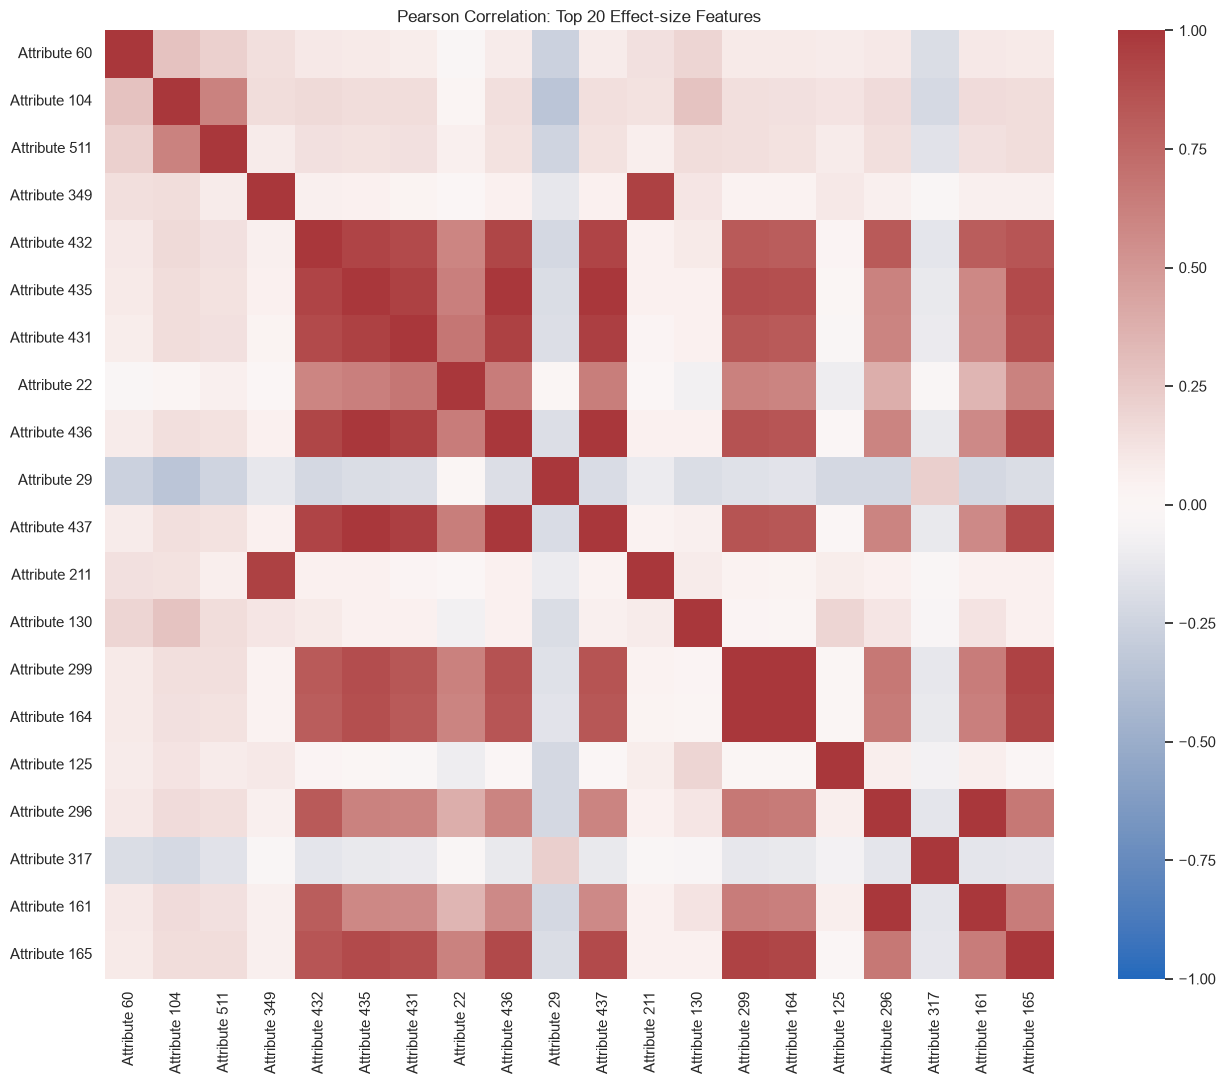

In [6]:
correlation = X.corr(method='pearson')
upper_mask = np.triu(np.ones(correlation.shape, dtype=bool), k=1)
pairs = correlation.where(upper_mask).stack().rename('correlation').reset_index()
pairs.columns = ['feature_a', 'feature_b', 'correlation']
pairs['abs_correlation'] = pairs['correlation'].abs()
top_correlation_pairs = pairs.sort_values('abs_correlation', ascending=False).head(30)
top_correlation_pairs.to_csv(REPORTS_DIR / 'eda_top_correlation_pairs.csv', index=False)
display(top_correlation_pairs)

top_features = top_effect.index.tolist()
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(X[top_features].corr(), cmap='vlag', center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Pearson Correlation: Top 20 Effect-size Features')
fig.tight_layout()
correlation_figure = FIGURES_DIR / 'eda_top20_effect_features_correlation.png'
fig.savefig(correlation_figure, dpi=160, bbox_inches='tight')
plt.show()

## 5. Timestamp patterns

Timestamp를 day-first 형식으로 parsing한다. 관측 순서와 주·월별 Fail rate만 확인한다. Metadata에 lot, wafer, 설비 ID가 없으므로 그러한 단위를 추정하지 않는다.

Invalid timestamps: 0
Observation period: 2008-07-19 11:55:00 to 2008-10-17 06:07:00
Observed days: 86; weeks: 13; months: 4


,timestamp,samples,fails,fail_rate
0,2008-07-01,63,14,0.222222
1,2008-08-01,555,51,0.091892
2,2008-09-01,590,17,0.028814
3,2008-10-01,359,22,0.061281


,date,samples,fails,fail_rate
5,2008-07-25,1,1,1.000000
2,2008-07-21,2,1,0.500000
20,2008-08-10,12,5,0.416667
9,2008-07-30,5,2,0.400000
8,2008-07-29,12,4,0.333333
26,2008-08-17,17,5,0.294118
0,2008-07-19,12,3,0.250000
7,2008-07-28,8,2,0.250000
77,2008-10-09,8,2,0.250000
10,2008-07-31,4,1,0.250000


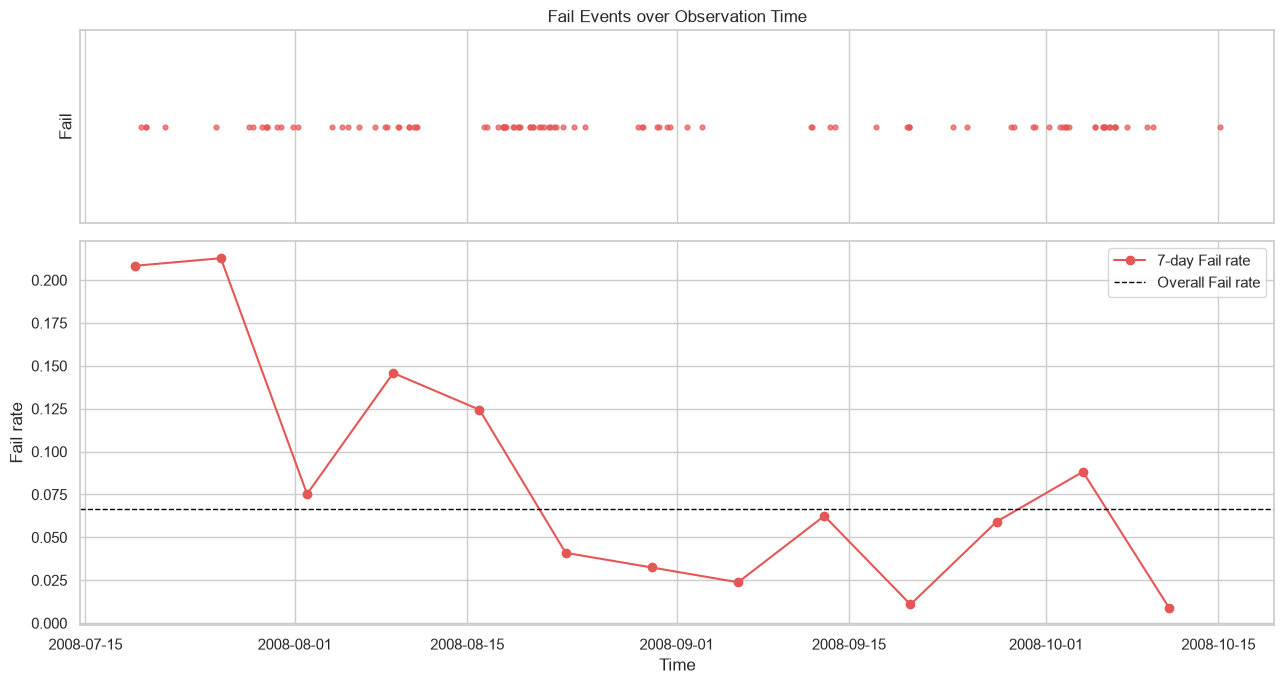

In [7]:
parsed_time = pd.to_datetime(df['timestamp'], format='mixed', dayfirst=True, errors='coerce')
invalid_timestamps = int(parsed_time.isna().sum())
time_df = pd.DataFrame({'timestamp': parsed_time, 'is_fail': target.eq(1).astype(int)}).dropna().sort_values('timestamp')
time_df['date'] = time_df['timestamp'].dt.date
daily = time_df.groupby('date').agg(samples=('is_fail', 'size'), fails=('is_fail', 'sum'), fail_rate=('is_fail', 'mean')).reset_index()
weekly = time_df.set_index('timestamp').resample('7D').agg(samples=('is_fail', 'size'), fails=('is_fail', 'sum'), fail_rate=('is_fail', 'mean')).reset_index()
monthly = time_df.set_index('timestamp').resample('MS').agg(samples=('is_fail', 'size'), fails=('is_fail', 'sum'), fail_rate=('is_fail', 'mean')).reset_index()
print(f'Invalid timestamps: {invalid_timestamps}')
print(f'Observation period: {time_df.timestamp.min()} to {time_df.timestamp.max()}')
print(f'Observed days: {len(daily)}; weeks: {len(weekly)}; months: {len(monthly)}')
display(monthly)
display(daily.sort_values(['fail_rate', 'samples'], ascending=False).head(15))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={'height_ratios': [1, 2]})
fail_times = time_df.loc[time_df['is_fail'].eq(1), 'timestamp']
axes[0].scatter(fail_times, np.ones(len(fail_times)), s=12, alpha=0.7, color='#E45756')
axes[0].set(title='Fail Events over Observation Time', yticks=[], ylabel='Fail')
axes[1].plot(weekly['timestamp'], weekly['fail_rate'], marker='o', color='#E45756', label='7-day Fail rate')
axes[1].axhline(target.eq(1).mean(), color='black', linestyle='--', linewidth=1, label='Overall Fail rate')
axes[1].set(ylabel='Fail rate', xlabel='Time')
axes[1].legend()
fig.tight_layout()
time_figure = FIGURES_DIR / 'eda_fail_timeline_weekly_rate.png'
fig.savefig(time_figure, dpi=160, bbox_inches='tight')
plt.show()

## 6. Reproducible summary: observed facts vs possible interpretations

In [8]:
strongest_pair = top_correlation_pairs.iloc[0]
highest_week = weekly.loc[weekly['fail_rate'].idxmax()]
summary = {
    'top_effect_features': top_effect.reset_index(names='feature')[['feature', 'hedges_g', 'abs_hedges_g', 'fdr_bh']].to_dict(orient='records'),
    'fdr_significant_feature_count': significant_count,
    'strongest_correlation_pair': strongest_pair.to_dict(),
    'invalid_timestamp_count': invalid_timestamps,
    'observation_start': str(time_df.timestamp.min()),
    'observation_end': str(time_df.timestamp.max()),
    'overall_fail_rate': float(target.eq(1).mean()),
    'highest_week_start': str(highest_week['timestamp']),
    'highest_week_samples': int(highest_week['samples']),
    'highest_week_fails': int(highest_week['fails']),
    'highest_week_fail_rate': float(highest_week['fail_rate']),
}
(REPORTS_DIR / 'eda_summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
display(Markdown(f'''### 관찰된 사실

- 절대 Hedges' g가 가장 큰 Feature는 **{top_effect.index[0]}**이며 g={top_effect.iloc[0]['hedges_g']:.3f}이다.
- Welch test에 BH-FDR을 적용했을 때 0.05 미만 Feature는 **{significant_count}개**다.
- 가장 강한 Pearson pair는 **{strongest_pair['feature_a']} / {strongest_pair['feature_b']}**, r={strongest_pair['correlation']:.4f}다.
- Timestamp {invalid_timestamps}개가 parsing에 실패했고, 관측 범위는 **{time_df.timestamp.min()} ~ {time_df.timestamp.max()}**다.
- 주간 Fail rate 최고 구간은 {highest_week['timestamp'].date()} 시작 주로, {int(highest_week['samples'])}개 중 {int(highest_week['fails'])}개 Fail ({highest_week['fail_rate']:.2%})이다.

### 가능한 해석

- 큰 효과크기는 해당 익명 측정값의 그룹 분리가 상대적으로 크다는 뜻이지만, 인과적 불량 원인임을 뜻하지 않는다.
- 높은 Feature 간 상관은 중복 정보나 함께 움직이는 측정 패턴일 수 있으나 실제 센서 관계는 metadata만으로 알 수 없다.
- 시간별 Fail 집중은 공정 변화 가능성을 탐색할 단서지만, lot·wafer·설비 ID가 없어 원인을 특정할 수 없다.
- Median 대치된 EDA 데이터의 결과이므로 원본 결측 메커니즘과 대치 효과를 함께 고려해야 한다.
- 다수의 FDR 유의 Feature가 있더라도 효과크기와 재현성 검증 없이 중요 Feature로 확정할 수 없다.
'''))
print(json.dumps(summary, indent=2, ensure_ascii=False))

### 관찰된 사실

- 절대 Hedges' g가 가장 큰 Feature는 **Attribute 60**이며 g=0.634이다.
- Welch test에 BH-FDR을 적용했을 때 0.05 미만 Feature는 **21개**다.
- 가장 강한 Pearson pair는 **Attribute 343 / Attribute 348**, r=1.0000다.
- Timestamp 0개가 parsing에 실패했고, 관측 범위는 **2008-07-19 11:55:00 ~ 2008-10-17 06:07:00**다.
- 주간 Fail rate 최고 구간은 2008-07-26 시작 주로, 47개 중 10개 Fail (21.28%)이다.

### 가능한 해석

- 큰 효과크기는 해당 익명 측정값의 그룹 분리가 상대적으로 크다는 뜻이지만, 인과적 불량 원인임을 뜻하지 않는다.
- 높은 Feature 간 상관은 중복 정보나 함께 움직이는 측정 패턴일 수 있으나 실제 센서 관계는 metadata만으로 알 수 없다.
- 시간별 Fail 집중은 공정 변화 가능성을 탐색할 단서지만, lot·wafer·설비 ID가 없어 원인을 특정할 수 없다.
- Median 대치된 EDA 데이터의 결과이므로 원본 결측 메커니즘과 대치 효과를 함께 고려해야 한다.
- 다수의 FDR 유의 Feature가 있더라도 효과크기와 재현성 검증 없이 중요 Feature로 확정할 수 없다.


{
  "top_effect_features": [
    {
      "feature": "Attribute 60",
      "hedges_g": 0.6337834890819123,
      "abs_hedges_g": 0.6337834890819123,
      "fdr_bh": 5.5996911908493654e-05
    },
    {
      "feature": "Attribute 104",
      "hedges_g": 0.6139118265143318,
      "abs_hedges_g": 0.6139118265143318,
      "fdr_bh": 8.888774293205257e-05
    },
    {
      "feature": "Attribute 511",
      "hedges_g": 0.5329697057028014,
      "abs_hedges_g": 0.5329697057028014,
      "fdr_bh": 0.012495321359430222
    },
    {
      "feature": "Attribute 349",
      "hedges_g": 0.5294469400496323,
      "abs_hedges_g": 0.5294469400496323,
      "fdr_bh": 0.13487178048995693
    },
    {
      "feature": "Attribute 432",
      "hedges_g": 0.48477730460470897,
      "abs_hedges_g": 0.48477730460470897,
      "fdr_bh": 0.17610484421557246
    },
    {
      "feature": "Attribute 435",
      "hedges_g": 0.4494614887144752,
      "abs_hedges_g": 0.4494614887144752,
      "fdr_bh": 0.26242849111

## Scope boundary

이 노트북은 탐색적 기술·비교 분석만 수행했다. Feature selection, PCA, SMOTE, 모델 학습 및 SHAP은 후속 단계로 남긴다.